# 04 · EDA — 05. Relación entre las features y el target

Quinto y último notebook del análisis exploratorio. Conecta los dos análisis previos:
las **stats de rendimiento** (notebook 04_04) con la **variable objetivo `log(salario)`** (notebook 04_02).

## Bloques abordados

1. **Correlación lineal** (Pearson): qué stats se mueven con el salario en línea recta.
2. **Correlación monótona** (Spearman): captura relaciones crecientes no necesariamente lineales.
3. **Visualización de las top features** vs `log(salario)` con regresión LOWESS.
4. **Análisis por posición**: las correlaciones cambian drásticamente entre porteros, defensas,
   centrocampistas y delanteros.
5. **Información mutua**: detección de relaciones no monótonas que las correlaciones se pierden.
6. **Conclusiones** y selección de features candidatas para los modelos.

⚠️ Recordatorio: trabajamos con `log(gross_annual_eur)` por la fuerte log-normalidad de la distribución
salarial (justificada en el notebook 04_02).

---

## 1. Imports y carga

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.feature_selection import mutual_info_regression

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100

ROOT  = Path.cwd().parents[1]
CLEAN = ROOT / 'data' / 'clean' / 'master_clean.csv'

df = pd.read_csv(CLEAN, dtype={'season': str})

# Filtramos a los registros con salario disponible
df_sal = df.dropna(subset=['gross_annual_eur']).copy()
df_sal['log_sal'] = np.log(df_sal['gross_annual_eur'])

print(f'Filas con salario disponible: {len(df_sal):,}')

# Variables stats
EXCLUDE = {'player_id', 'team_id', 'gross_annual_eur', 'gross_weekly_eur', 'age', 'download_date'}
num_cols   = df.select_dtypes(include=[np.number]).columns.tolist()
stats_cols = [c for c in num_cols if c not in EXCLUDE]
print(f'Variables stats:              {len(stats_cols)}')

Filas con salario disponible: 18,463
Variables stats:              110


## 2. Correlación de Pearson con `log(salario)`

La correlación de Pearson mide la **dependencia lineal** entre dos variables continuas:

$$r_{XY} = \dfrac{\text{Cov}(X, Y)}{\sigma_X \sigma_Y} \in [-1, 1]$$

Sus limitaciones: solo captura relaciones lineales y es sensible a outliers.

In [2]:
corr_pearson = (
    df_sal[stats_cols + ['log_sal']]
    .corr(method='pearson')['log_sal']
    .drop('log_sal')
    .sort_values(ascending=False)
)

print(f'=== Top 15 correlaciones POSITIVAS con log(salario) ===')
display(corr_pearson.head(15).round(3).to_frame('Pearson r'))

=== Top 15 correlaciones POSITIVAS con log(salario) ===


,Pearson r
accurateFinalThirdPasses,0.396
accurateOppositionHalfPasses,0.394
totalOppositionHalfPasses,0.379
accuratePasses,0.351
totalPasses,0.347
touches,0.345
totalRating,0.340
countRating,0.324
expectedAssists,0.324
appearances,0.318


In [3]:
print(f'=== Top 15 correlaciones más bajas (cercanas a 0) ===')
display(corr_pearson.abs().nsmallest(15).round(3).to_frame('|Pearson r|'))

=== Top 15 correlaciones más bajas (cercanas a 0) ===


,|Pearson r|
penaltyConceded,0.003
crossesNotClaimed,0.009
goalsPrevented,0.010
penaltySave,0.013
yellowRedCards,0.016
penaltyFaced,0.018
ownGoals,0.024
directRedCards,0.025
redCards,0.029
savesCaught,0.032


**Hallazgos importantes:**

- Las **correlaciones más altas** están en torno a **0.40**. Ninguna feature sola predice el salario
  fuertemente: el modelo final tendrá que combinar muchas señales.
- El **top de correlaciones positivas** está dominado por variables de **volumen y exposición**
  (`accurateFinalThirdPasses`, `totalPasses`, `touches`, `appearances`, `minutesPlayed`...). Es decir,
  **el primer factor que predice el salario es jugar mucho y tocar mucho la pelota**.
- Las stats "específicas" (paradas, tarjetas rojas, autogoles...) tienen correlaciones casi nulas con
  el salario en el conjunto global. Esto se debe a que son **estructuralmente cero** para gran parte
  del dataset (un delantero no para tiros, etc.). Su poder predictivo se revela al **segmentar por posición**
  (sección 4).

⚠️ **Sin correlaciones negativas significativas:** ninguna stat se asocia con cobrar menos. Esto refuerza
que el salario premia el rendimiento, no penaliza errores.

## 3. Correlación de Spearman

La correlación de Spearman mide la **dependencia monótona**: detecta relaciones crecientes/decrecientes
aunque no sean lineales. Se calcula aplicando Pearson sobre los **rangos** de las variables:

$$\rho = 1 - \dfrac{6 \sum d_i^2}{n(n^2-1)}$$

donde $d_i$ es la diferencia de rangos entre cada par de observaciones.

**Es más robusta a outliers** y por eso es especialmente útil en este dataset, donde tanto las stats
como el salario tienen colas largas.

In [4]:
corr_spearman = (
    df_sal[stats_cols + ['log_sal']]
    .corr(method='spearman')['log_sal']
    .drop('log_sal')
    .sort_values(ascending=False)
)

# Comparación lado a lado
comparacion = pd.DataFrame({
    'Pearson':  corr_pearson,
    'Spearman': corr_spearman,
    'Δ (Sp - Pe)': corr_spearman - corr_pearson
}).sort_values('Spearman', ascending=False)

print('=== Top 15 correlaciones (ordenadas por Spearman) ===')
display(comparacion.head(15).round(3))

=== Top 15 correlaciones (ordenadas por Spearman) ===


,Pearson,Spearman,Δ (Sp - Pe)
accurateFinalThirdPasses,0.396,0.387,-0.010
rating,0.248,0.387,0.139
accurateOppositionHalfPasses,0.394,0.386,-0.007
totalOppositionHalfPasses,0.379,0.373,-0.006
accuratePasses,0.351,0.363,0.013
totalPasses,0.347,0.355,0.009
touches,0.345,0.346,0.001
expectedAssists,0.324,0.334,0.010
totalRating,0.340,0.316,-0.024
goalsAssistsSum,0.317,0.316,-0.001


**Comparación Pearson vs Spearman:**

- En general, los valores son muy similares — la diferencia (Δ) es pequeña. Esto indica que las
  relaciones entre stats y salario son **aproximadamente lineales tras la transformación log**.
- Una variable destacada: **`rating`** sube considerablemente en Spearman frente a Pearson. Esto se
  debe a que `rating` está acotado en un rango estrecho (6-8), lo que genera una relación monótona
  pero no lineal con el salario. Spearman captura esa monotonicidad mejor que Pearson.
- Las variables que dominan ambos rankings son las mismas (volumen + creación), lo que aporta
  robustez al diagnóstico.

## 4. Visualización: top features vs `log(salario)`

Para las 6 stats con mayor correlación se muestran scatterplots con una **regresión LOWESS**
(Locally Weighted Scatterplot Smoothing) superpuesta. LOWESS ajusta una curva suave sin asumir
forma funcional, lo que permite detectar **no linealidades** que las correlaciones podrían ocultar.

Variables a visualizar: ['accurateFinalThirdPasses', 'accurateOppositionHalfPasses', 'totalOppositionHalfPasses', 'accuratePasses', 'totalPasses', 'touches']


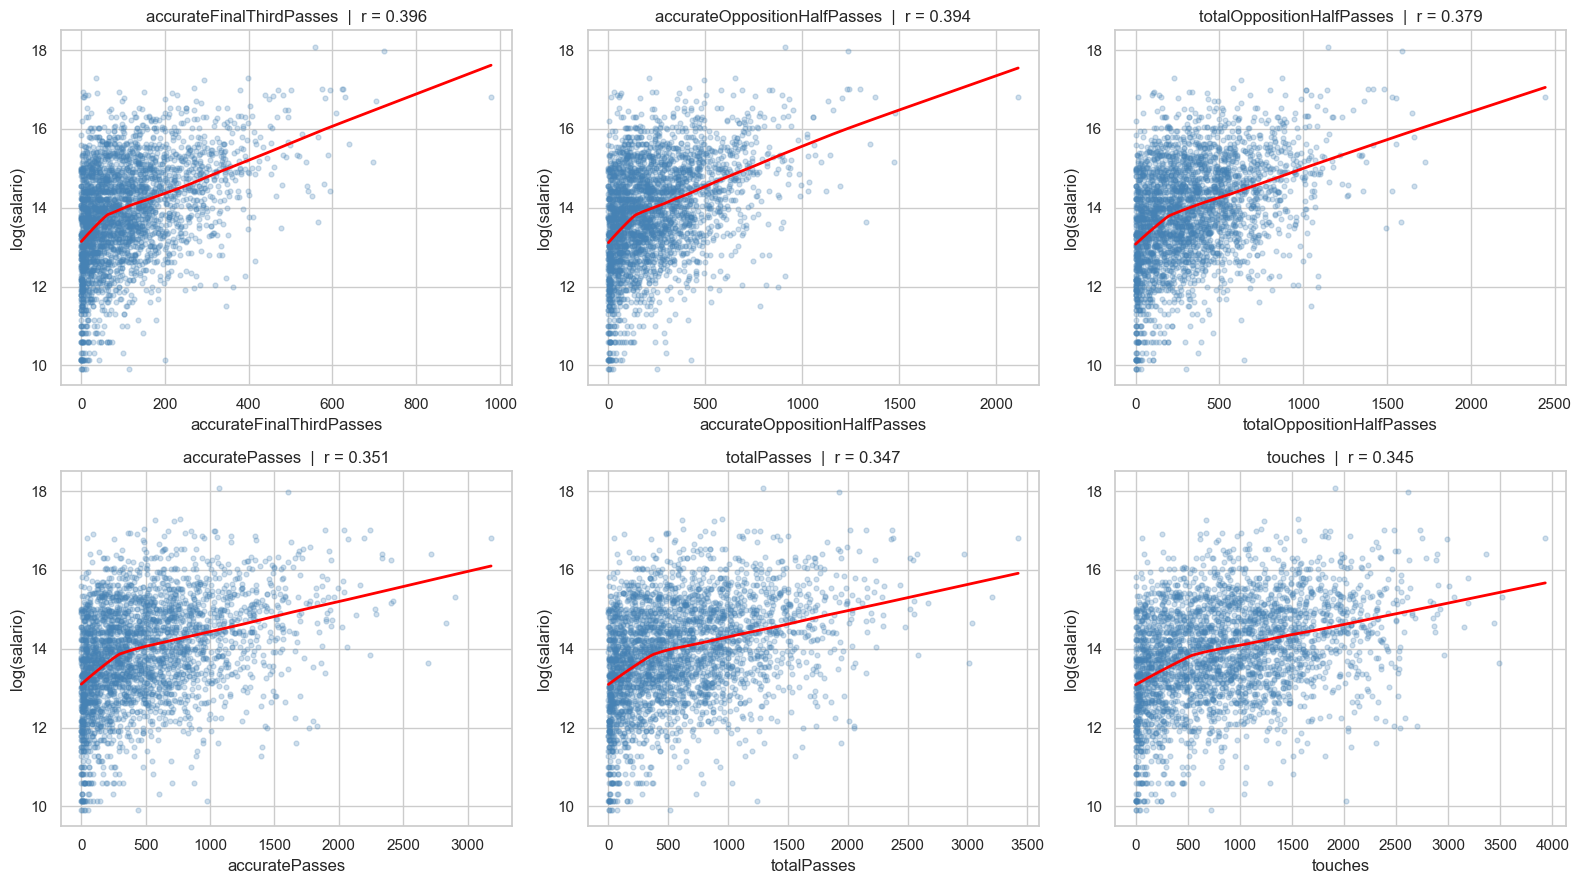

In [5]:
top6 = corr_pearson.head(6).index.tolist()
print(f'Variables a visualizar: {top6}')

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flat, top6):
    # Submuestra para velocidad de plotting
    sample = df_sal[[col, 'log_sal']].dropna().sample(n=min(3000, len(df_sal)), random_state=42)
    sns.regplot(data=sample, x=col, y='log_sal',
                lowess=True, scatter_kws={'alpha': 0.25, 's': 12, 'color': 'steelblue'},
                line_kws={'color': 'red', 'lw': 2}, ax=ax)
    r = df_sal[[col, 'log_sal']].corr().iloc[0, 1]
    ax.set_title(f'{col}  |  r = {r:.3f}')
    ax.set_xlabel(col)
    ax.set_ylabel('log(salario)')

plt.tight_layout()
plt.show()

**Lectura:** las curvas LOWESS rojas muestran que las relaciones son **monótonas crecientes**, con
algunas curvaturas leves en los extremos. La nube de puntos es muy dispersa, lo que confirma que
ninguna variable sola explica el salario; hace falta un modelo multivariante.

## 5. Análisis por posición

Aquí está el hallazgo metodológicamente más importante: **las features predictivas del salario son
completamente distintas según la posición del jugador**. Un análisis global mezcla manzanas y peras.

In [6]:
orden_pos = ['K', 'D', 'M', 'F']
nombres_pos = {'K': 'Portero', 'D': 'Defensa', 'M': 'Mediocentro', 'F': 'Delantero'}

corr_por_pos = {}
for pos in orden_pos:
    sub = df_sal[df_sal['position'] == pos]
    if len(sub) < 100:
        continue
    c = (
        sub[stats_cols + ['log_sal']]
        .corr(method='spearman')['log_sal']
        .drop('log_sal')
        .sort_values(ascending=False)
    )
    corr_por_pos[pos] = c
    print(f'\n=== Top 10 features para {nombres_pos[pos]} (N={len(sub):,}) ===')
    display(c.head(10).round(3).to_frame(f'Spearman ρ'))


=== Top 10 features para Portero (N=1,489) ===


,Spearman ρ
accurateOwnHalfPasses,0.483
totalOwnHalfPasses,0.477
cleanSheet,0.470
accuratePasses,0.468
matchesStarted,0.436
totalRating,0.434
minutesPlayed,0.434
countRating,0.434
totalPasses,0.433
appearances,0.433



=== Top 10 features para Defensa (N=6,328) ===


,Spearman ρ
accurateOppositionHalfPasses,0.381
rating,0.371
accuratePasses,0.358
accurateFinalThirdPasses,0.347
totalOppositionHalfPasses,0.343
totalPasses,0.343
accurateOwnHalfPasses,0.317
touches,0.316
totalOwnHalfPasses,0.311
accuratePassesPercentage,0.296



=== Top 10 features para Mediocentro (N=4,161) ===


,Spearman ρ
accurateFinalThirdPasses,0.456
accurateOppositionHalfPasses,0.453
rating,0.448
totalOppositionHalfPasses,0.434
accuratePasses,0.428
totalPasses,0.418
touches,0.403
expectedAssists,0.401
accurateOwnHalfPasses,0.382
totalOwnHalfPasses,0.378



=== Top 10 features para Delantero (N=6,485) ===


,Spearman ρ
shotsFromInsideTheBox,0.439
goalsAssistsSum,0.439
expectedGoals,0.439
accurateFinalThirdPasses,0.436
totalShots,0.432
shotsOnTarget,0.426
rating,0.425
expectedAssists,0.422
accurateOppositionHalfPasses,0.421
blockedShots,0.420


**Hallazgos clave por posición:**

- **Porteros (K):** las stats más predictivas son `cleanSheet`, `accurateOwnHalfPasses` y `matchesStarted`.
  Es decir, el portero mejor pagado es el que **juega de titular en un equipo bueno** (clean sheets) y
  **construye juego desde atrás** con su pie. Las paradas en sí no aparecen en el top 5: importa más
  estar en un equipo bueno que parar muchos tiros.

- **Defensas (D):** dominan stats de **pase progresivo** (`accurateOppositionHalfPasses`,
  `accurateFinalThirdPasses`). El defensa mejor pagado no es el que más entradas hace, sino el que
  **inicia juego y avanza la pelota** — el defensa "moderno" (Van Dijk, Rüdiger, Pau Cubarsí).

- **Mediocentros (M):** aparece `goalsPrevented` con la correlación más alta (ρ ≈ 0.52). Esto es **muy raro
  para una posición de campo** y motivó una auditoría detallada de la variable, documentada en la
  sección 5.1 a continuación.

- **Delanteros (F):** dominan, como cabría esperar, las stats ofensivas: `goalsAssistsSum`,
  `totalShots`, `expectedGoals`, `shotsFromInsideTheBox`. Aquí el patrón es transparente: cuanto más
  produces frente a portería, más cobras.

### 5.1 Auditoría: anomalía de `goalsPrevented` en jugadores de campo

La elevada correlación detectada para mediocentros (ρ ≈ 0.52) sugiere a primera vista que algunos
**mediocentros defensivos posicionales** (Casemiro, Rodri, Busquets...) podrían estar capturando bien
la métrica de "ocasiones evitadas". Sin embargo, una inspección más detallada revela un **fenómeno
estructural en los datos** que requiere documentación.

`goalsPrevented` está definida como una métrica **estrictamente de portero** (xG concedidos − goles
concedidos), por lo que debería ser nula para todos los jugadores de campo. La detección de valores
no nulos en posiciones distintas de `K` es indicativo de un problema en la fuente.

In [7]:
# Detectar todos los registros con goalsPrevented no nulo en jugadores de campo
mask_anomalia = df['goalsPrevented'].notna() & (df['position'].isin(['D', 'M', 'F']))
n_anomalia    = mask_anomalia.sum()

print(f'Registros de jugadores de campo con goalsPrevented no nulo: {n_anomalia}')

if n_anomalia > 0:
    print('\n=== Distribución por country × season ===')
    display(df[mask_anomalia].groupby(['country','season']).size().unstack(fill_value=0))

Registros de jugadores de campo con goalsPrevented no nulo: 17058

=== Distribución por country × season ===


season,2021,2122,2223,2324,2425,2526
country,,,,,,
england,451,456,481,479,494,456
france,465,489,485,437,440,413
germany,435,446,447,431,431,428
italy,506,512,506,504,519,475
spain,461,493,469,479,474,461
turkey,572,507,495,554,488,419


In [8]:
# Inspeccionar valores de goalsPrevented por equipo en el caso más concentrado (England 22/23)
sub = df[mask_anomalia & (df['country']=='england') & (df['season']=='2223')]

print(f'Casos en England 22/23: {len(sub)}')
print('\n=== Valores únicos de goalsPrevented por equipo ===')
display(
    sub.groupby('team')['goalsPrevented']
       .agg(['nunique','first','count'])
       .rename(columns={'nunique': 'valores_distintos', 'first': 'valor', 'count': 'n_jugadores'})
)

Casos en England 22/23: 481

=== Valores únicos de goalsPrevented por equipo ===


,valores_distintos,valor,n_jugadores
team,,,
Arsenal,1,0.00,22
Aston Villa,1,0.00,22
Bournemouth,1,0.00,28
Brentford,2,-0.34,22
Brighton & Hove Albion,1,0.00,21
Chelsea,1,0.00,28
Crystal Palace,1,0.00,22
Everton,1,0.00,22
Fulham,1,0.00,25


**Diagnóstico:** todos los jugadores de un mismo equipo presentan **exactamente el mismo valor**
de `goalsPrevented`. Esto indica que en estos casos la variable no representa una stat individual,
sino la **stat colectiva del portero del equipo**, replicada incorrectamente en cada jugador de
campo durante la extracción. Es un sesgo estructural de la fuente, no un dato real de rendimiento.

El fenómeno está concentrado en **England 22/23** (45 de los 66 casos totales) y se distribuye en
toda la plantilla de algunos equipos (Newcastle, Brentford, Manchester United, West Ham). En las
demás temporadas y ligas aparecen casos puntuales aislados, todos con el mismo patrón.

**Por qué esto inflaba la correlación de los mediocentros:** los 9 mediocentros afectados de la
Premier 22/23 son jugadores de equipos top (Declan Rice, Bruno Guimarães, Lucas Paquetá...), todos
con salarios elevados. Al ser los únicos mediocentros del dataset con `goalsPrevented` poblado, su
valor (heredado del portero del equipo) correlaciona artificialmente con un salario alto. Es un caso
clásico de **correlación espuria** debido a sesgo de muestreo.

**Decisión:** se corregirá en el feature engineering (fase 05) forzando a `NaN` todos los valores de
`goalsPrevented` para jugadores cuya posición no sea `K`. Esta limpieza eliminará el sesgo y
restaurará la interpretabilidad de la variable.

## 6. Información mutua: detectando relaciones no monótonas

La correlación (Pearson o Spearman) solo detecta relaciones **monótonas**. Si una variable tiene una
relación en forma de "U" o de "campana" con el salario (por ejemplo, los jugadores muy jóvenes y los
muy mayores cobran menos), la correlación dará valores cercanos a cero aunque la relación sea fuerte.

La **información mutua** mide cualquier tipo de dependencia estadística:

$$I(X; Y) = \sum_{x,y} p(x,y) \log \dfrac{p(x,y)}{p(x)\,p(y)}$$

Es siempre ≥ 0, y vale 0 únicamente si X e Y son independientes.

In [9]:
# Imputamos nulos con mediana solo para el cálculo de información mutua
X_im = df_sal[stats_cols].fillna(df_sal[stats_cols].median(numeric_only=True))
y    = df_sal['log_sal']

# Submuestreo para acelerar (mutual_info_regression es O(n²) en el peor caso)
sample_idx = X_im.sample(n=min(5000, len(X_im)), random_state=42).index
X_im_s = X_im.loc[sample_idx]
y_s    = y.loc[sample_idx]

mi = mutual_info_regression(X_im_s, y_s, random_state=42)
mi_series = pd.Series(mi, index=stats_cols).sort_values(ascending=False)

print('=== Top 15 features por Información Mutua ===')
display(mi_series.head(15).round(4).to_frame('MI'))

=== Top 15 features por Información Mutua ===


,MI
accurateFinalThirdPasses,0.1230
touches,0.1103
rating,0.1090
accurateOppositionHalfPasses,0.1078
totalOppositionHalfPasses,0.1075
totalPasses,0.1023
accuratePasses,0.1021
accurateOwnHalfPasses,0.0966
expectedAssists,0.0908
minutesPlayed,0.0892


In [10]:
# Comparación: top 15 por MI vs top 15 por Spearman
top_mi = set(mi_series.head(15).index)
top_sp = set(corr_spearman.abs().nlargest(15).index)

solo_mi = top_mi - top_sp
solo_sp = top_sp - top_mi
ambas   = top_mi & top_sp

print(f'En ambos rankings (top 15): {len(ambas)} variables')
print(f'\nSolo en top MI (relación no monótona):')
for v in sorted(solo_mi):
    print(f'   {v}: MI={mi_series[v]:.3f}, Spearman={corr_spearman[v]:.3f}')

print(f'\nSolo en top Spearman:')
for v in sorted(solo_sp):
    print(f'   {v}')

En ambos rankings (top 15): 11 variables

Solo en top MI (relación no monótona):
   accurateOwnHalfPasses: MI=0.097, Spearman=0.298
   shotsFromInsideTheBox: MI=0.078, Spearman=0.303
   shotsOffTarget: MI=0.077, Spearman=0.278
   totwAppearances: MI=0.086, Spearman=0.299

Solo en top Spearman:
   goalsAssistsSum
   keyPasses
   totalAttemptAssist
   totalShots


**Lectura:** la información mutua confirma que las features importantes ya identificadas por Spearman
mantienen su poder predictivo. Las variables que aparecen solo en el ranking de MI son candidatas a
relaciones no monótonas con el salario, que un modelo no lineal (Random Forest, Gradient Boosting)
podrá explotar pero un modelo lineal no.

**Implicación:** el dataset se beneficiará probablemente más de **modelos no lineales** que de
regresión lineal pura.

## 7. Resumen y selección de features candidatas

### Hallazgos principales

| Aspecto | Resultado |
|---|---|
| **Correlación máxima individual** | r ≈ 0.40 — ninguna feature predice fuertemente sola |
| **Variables más predictivas (global)** | Volumen y exposición (`accurateFinalThirdPasses`, `totalPasses`, `touches`...) |
| **Pearson vs Spearman** | Muy similares: las relaciones son aproximadamente lineales tras la transformación log |
| **Información mutua** | Identifica relaciones no monótonas adicionales — favorece modelos no lineales |
| **Diferencias por posición** | Drásticas: las features importantes son completamente distintas para K/D/M/F |

### Decisiones que se trasladan a las fases 05 y 06

1. **Modelado segmentado por posición:** entrenar 4 modelos separados (K, D, M, F) o un único modelo con
   interacciones `posición × stat`. La decisión final se hará tras evaluar empíricamente ambas opciones.

2. **Preferencia por modelos no lineales:** XGBoost, Random Forest, Gradient Boosting. La información
   mutua sugiere que existen relaciones que un modelo lineal no capturaría.

3. **Feature selection:** combinar criterios complementarios — correlación con target + información mutua
   + clustering de redundancia (notebook 04_04). No basta con quedarse con las "top correlacionadas":
   muchas son redundantes entre sí.

4. **Atención a `rating`:** aunque tiene varianza relativa baja (vista en 04_04), su correlación de
   Spearman es alta. Es candidata firme a feature en el modelo.

5. **Limpieza de `goalsPrevented`:** forzar a `NaN` los valores en jugadores de campo
   (D, M, F), corrigiendo el sesgo estructural detectado en la sección 5.1.

6. **Stats per-90 minutos:** las correlaciones globales están dominadas por el volumen
   (jugar mucho → cobrar mucho). Conviene crear versiones per-90 de las stats ofensivas/defensivas
   en el FE para aislar el "qué bien lo hace" del "cuánto lo hace".

### Cierre del EDA

Con este notebook se cierra el análisis exploratorio. El siguiente paso es la **fase 05 (feature
engineering)**, donde se concretarán las decisiones acumuladas a lo largo de los 5 notebooks del EDA.